# 제주 농산물 가격 예측 통합 고도화 프로젝트 (GeminiCLI6.ipynb - Fixed)

이 노트북은 이전 버전의 구조적 오류를 해결하고 안정적인 피처 중요도 분석을 수행합니다.
1. **학습 모델 접근 수정**: VotingRegressor 내부의 학습된 모델에서 피처 중요도 추출
2. **인덱스 안정화**: 그룹별 데이터 분리 시 인덱스 초기화로 OOF 계산 오류 방지
3. **피처 간소화**: EMA를 제거하고 날짜 및 명절 거리 특성에 집중
4. **5-Fold 교차 검증**: 로컬 MAE/RMSE 확인
5. **최종 결과물**: submission35.csv

## 1. 라이브러리 및 폰트 설정

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

try:
    from korean_font import set_korean_font
    set_korean_font()
    print("한글 폰트 설정 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
한글 폰트 설정 완료


## 2. 데이터 전처리

In [2]:
DATA_PATH = './data/'
train_raw = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train_raw['item'] == item) & (train_raw['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train_raw[(train_raw['item'] == item) & (train_raw['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train_raw.loc[mask, 'price(원/kg)'] = mean_val

print("이상치 처리 완료")

이상치 처리 완료


## 3. 특성 엔지니어링

In [3]:
SEOLLAL_DATES = [pd.Timestamp(d) for d in ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22']]
CHUSEOK_DATES = [pd.Timestamp(d) for d in ['2019-09-13', '2020-10-01', '2021-09-21', '2022-09-10', '2023-09-29']]

def add_features(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    
    df['dist_seollal'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in SEOLLAL_DATES), 30))
    df['dist_chuseok'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in CHUSEOK_DATES), 30))
    
    kr_holidays = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
    return df

train = add_features(train_raw)
test = add_features(test_raw)

no_holi_dates = train[(train['holiday'] == 1) & (train['price(원/kg)'] > 0)]['timestamp'].unique()
train.loc[train['timestamp'].isin(no_holi_dates), 'holiday'] = 0
test.loc[test['timestamp'].isin(no_holi_dates), 'holiday'] = 0

print("특성 엔지니어링 완료")

특성 엔지니어링 완료


## 4. 모델링 준비 (Indexing 보정)

In [4]:
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train[col]) for col in le_cols}
for col in le_cols:
    train[col] = le_dict[col].transform(train[col])
    test[col] = le_dict[col].transform(test[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
train['target'] = np.where(train['item'] == item_codes['TG'], np.sqrt(train['price(원/kg)']), train['price(원/kg)'])

features = ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok']

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[features]), columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]), columns=features)
print("모델링 준비 완료")

모델링 준비 완료


## 5. 5-Fold 학습 및 피처 중요도 시각화

TG 그룹 학습...
Fold 1 | MAE: 1114.25
Fold 2 | MAE: 1034.07
Fold 3 | MAE: 1080.14
Fold 4 | MAE: 1143.09
Fold 5 | MAE: 1117.95
==> TG Overall | MAE: 1097.90 | RMSE: 1779.49


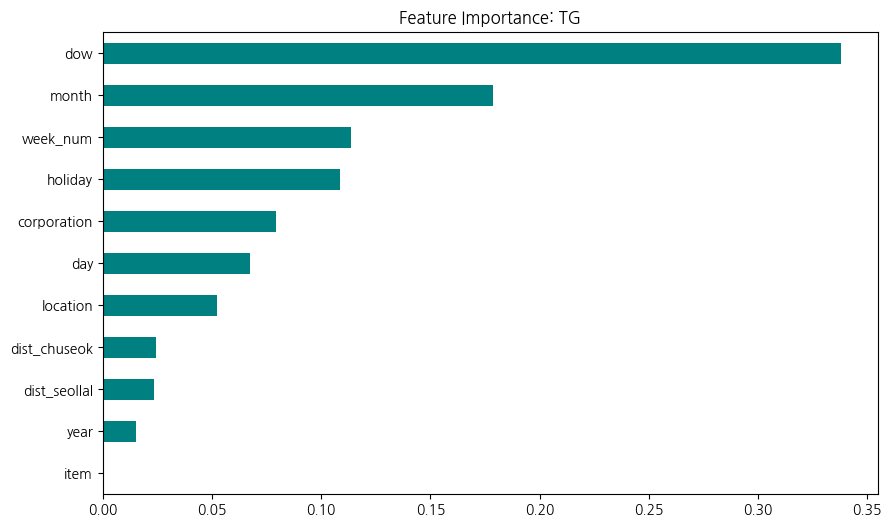

RD & CR 그룹 학습...
Fold 1 | MAE: 149.91
Fold 2 | MAE: 154.24
Fold 3 | MAE: 152.14
Fold 4 | MAE: 148.99
Fold 5 | MAE: 149.68
==> RD_CR Overall | MAE: 150.99 | RMSE: 277.47


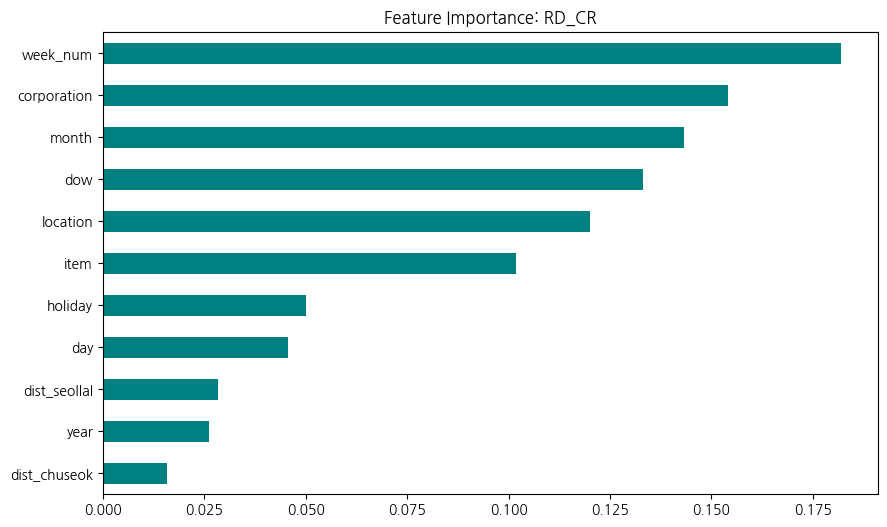

BC & CB 그룹 학습...
Fold 1 | MAE: 332.01
Fold 2 | MAE: 329.32
Fold 3 | MAE: 332.35
Fold 4 | MAE: 327.85
Fold 5 | MAE: 336.41
==> BC_CB Overall | MAE: 331.59 | RMSE: 591.93


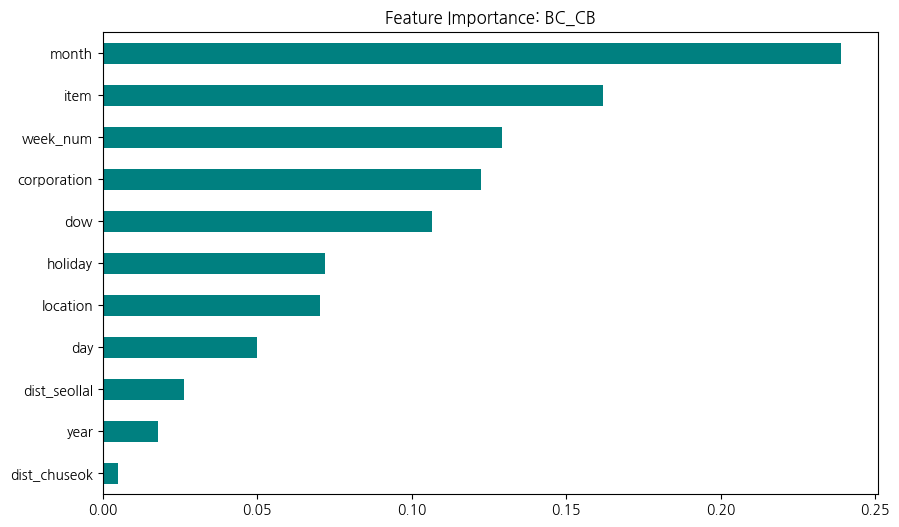

In [5]:
def train_group_with_importance_fixed(df, scaled_df, target_col, test_scaled_df, is_tg=False, group_name=""):
    # 인덱스 초기화 (K-Fold 및 마스킹 안전성 확보)
    df = df.reset_index(drop=True)
    scaled_df = scaled_df.reset_index(drop=True)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_preds = []
    oof_preds = np.zeros(len(df))
    importances = pd.DataFrame(index=features)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        X_train, y_train = scaled_df.iloc[train_idx], df[target_col].iloc[train_idx]
        X_val, y_val = scaled_df.iloc[val_idx], df[target_col].iloc[val_idx]
        
        ensemble = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42, verbose=-1)),
            ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)),
            ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=42, verbose=0)),
            ('ridge', Ridge(alpha=1.0))
        ])
        
        ensemble.fit(X_train, y_train)
        val_pred = ensemble.predict(X_val)
        oof_preds[val_idx] = val_pred
        
        # 학습된 내부 모델에서 중요도 추출
        lgbm_imp = ensemble.named_estimators_['lgbm'].feature_importances_
        xgb_imp = ensemble.named_estimators_['xgb'].feature_importances_
        cat_imp = ensemble.named_estimators_['cat'].get_feature_importance()
        
        # 정규화 후 평균
        importances[f'fold_{fold+1}'] = (lgbm_imp/lgbm_imp.sum() + xgb_imp/xgb_imp.sum() + cat_imp/cat_imp.sum()) / 3
        
        y_val_orig = np.power(y_val, 2) if is_tg else y_val
        val_pred_orig = np.power(np.maximum(0, val_pred), 2) if is_tg else np.maximum(0, val_pred)
        
        # 검증 시 일요일 보정 (.values 사용)
        val_pred_orig[df['dow'].iloc[val_idx].values == 6] = 0
        
        print(f"Fold {fold+1} | MAE: {mean_absolute_error(y_val_orig, val_pred_orig):.2f}")
        fold_preds.append(ensemble.predict(test_scaled_df))
    
    # 전체 OOF 스코어
    oof_orig = np.power(np.maximum(0, oof_preds), 2) if is_tg else np.maximum(0, oof_preds)
    target_orig = np.power(df[target_col], 2) if is_tg else df[target_col]
    oof_orig[df['dow'].values == 6] = 0
    
    print(f"==> {group_name} Overall | MAE: {mean_absolute_error(target_orig, oof_orig):.2f} | RMSE: {np.sqrt(mean_squared_error(target_orig, oof_orig)):.2f}")
    
    # 중요도 시각화
    plt.figure(figsize=(10, 6))
    importances.mean(axis=1).sort_values().plot(kind='barh', color='teal', title=f'Feature Importance: {group_name}')
    plt.show()
    
    return np.mean(fold_preds, axis=0)

print("TG 그룹 학습...")
tg_mask = train['item'] == item_codes['TG']
pred_tg = train_group_with_importance_fixed(train[tg_mask], train_scaled[tg_mask], 'target', test_scaled[test['item']==item_codes['TG']], True, "TG")

print("RD & CR 그룹 학습...")
rd_cr_mask = train['item'].isin([item_codes['RD'], item_codes['CR']])
pred_rd_cr = train_group_with_importance_fixed(train[rd_cr_mask], train_scaled[rd_cr_mask], 'target', test_scaled[test['item'].isin([item_codes['RD'], item_codes['CR']])], False, "RD_CR")

print("BC & CB 그룹 학습...")
bc_cb_mask = train['item'].isin([item_codes['BC'], item_codes['CB']])
pred_bc_cb = train_group_with_importance_fixed(train[bc_cb_mask], train_scaled[bc_cb_mask], 'target', test_scaled[test['item'].isin([item_codes['BC'], item_codes['CB']])], False, "BC_CB")

## 6. 후처리

In [6]:
test_tg = test[test['item'] == item_codes['TG']].copy()
test_rd_cr = test[test['item'].isin([item_codes['RD'], item_codes['CR']])].copy()
test_bc_cb = test[test['item'].isin([item_codes['BC'], item_codes['CB']])].copy()

test_tg['answer'] = np.power(np.maximum(0, pred_tg), 2)
test_rd_cr['answer'] = np.maximum(0, pred_rd_cr)
test_bc_cb['answer'] = np.maximum(0, pred_bc_cb)

test_tg.loc[test_tg['answer'] < 400, 'answer'] = 0
for df in [test_tg, test_rd_cr, test_bc_cb]:
    df.loc[df['dow'] == 6, 'answer'] = 0

total_results = pd.concat([test_tg, test_rd_cr, test_bc_cb])
print("예측 및 후처리 완료")

예측 및 후처리 완료


## 7. 시각화 (최종 추세)

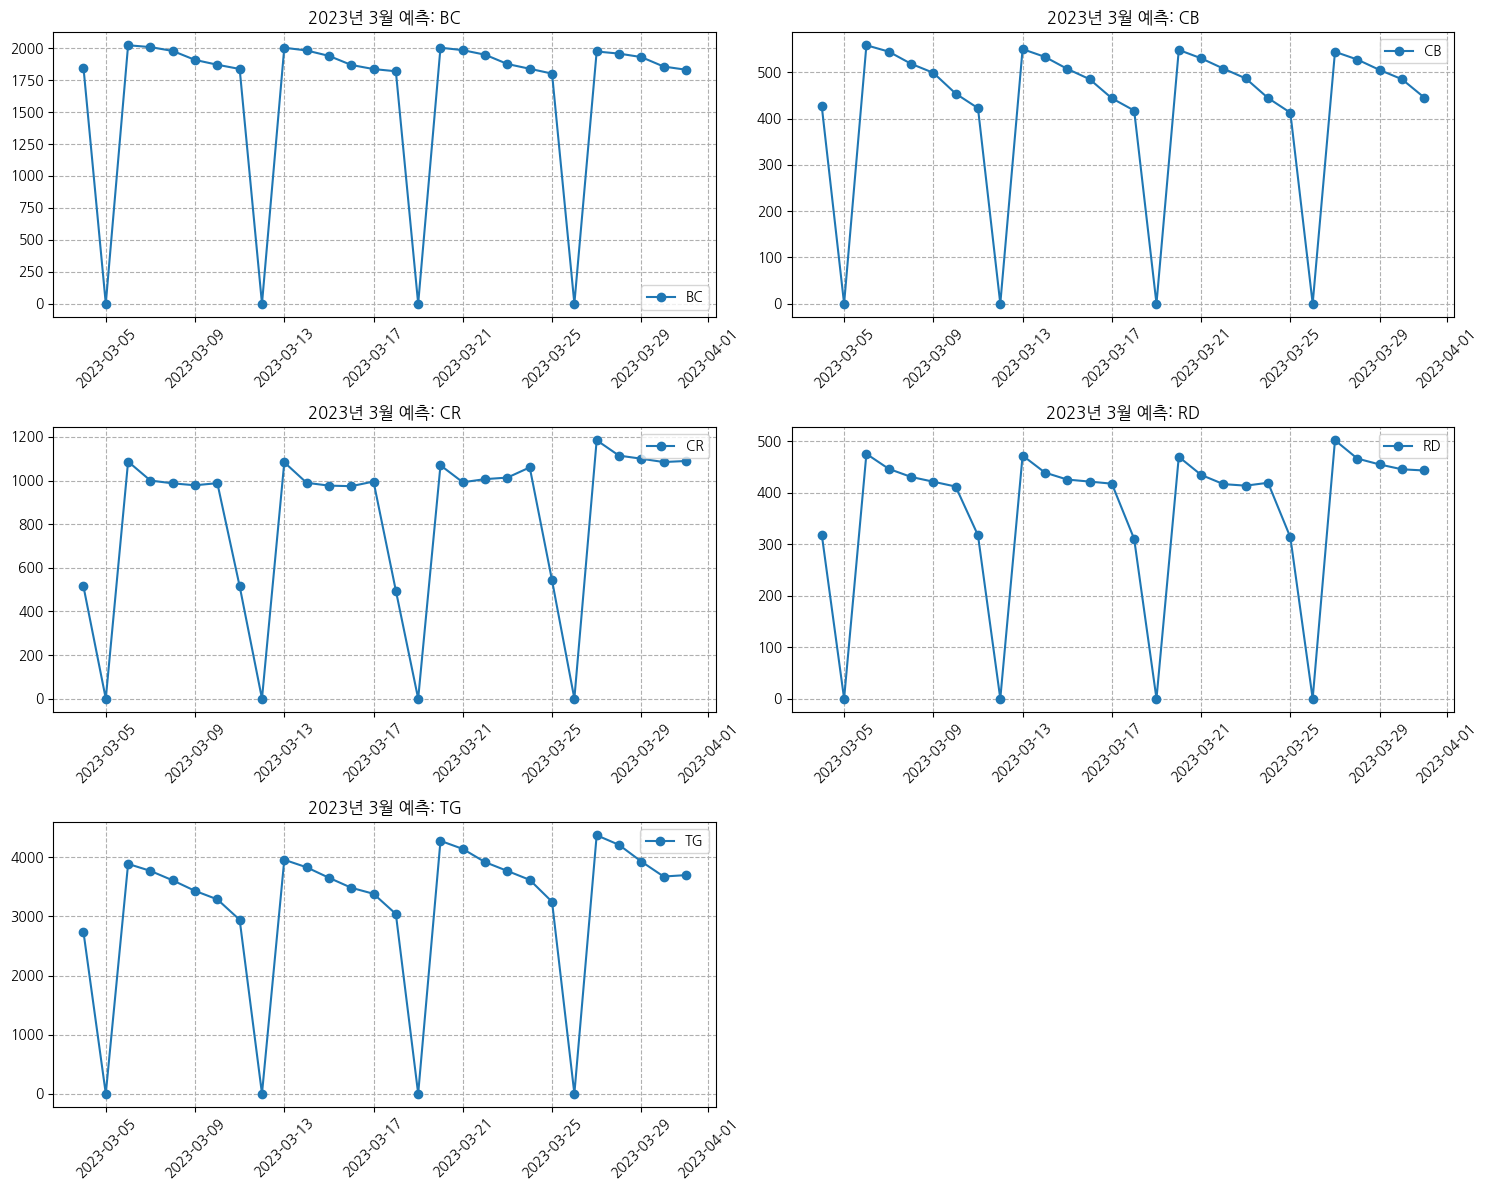

In [7]:
plt.figure(figsize=(15, 12))
items = le_dict['item'].classes_
for i, item_name in enumerate(items):
    plt.subplot(3, 2, i+1)
    item_code = le_dict['item'].transform([item_name])[0]
    data = total_results[total_results['item'] == item_code]
    daily = data.groupby('timestamp')['answer'].mean()
    plt.plot(daily.index, daily.values, marker='o', label=item_name)
    plt.title(f'2023년 3월 예측: {item_name}')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--')
    plt.legend()
plt.tight_layout()
plt.show()

## 8. 결과 저장

In [8]:
sample_sub = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))
submission = pd.merge(sample_sub[['ID']], total_results[['ID', 'answer']], on='ID', how='left')
submission.to_csv('submission35.csv', index=False)
print("submission35.csv 저장 완료")

submission35.csv 저장 완료
